# 📋 09 · Manager Full Walkthrough — Fleet Alert Anticipation

> **Objetivo deste notebook:** apresentar, de forma completa e acessível, todo o
> raciocínio do projeto — do problema à recomendação operacional — para que qualquer
> gestor possa entender as decisões tomadas, validar os resultados e decidir sobre
> adoção do modelo.

## O que você vai encontrar aqui

| Seção | Conteúdo |
|---|---|
| 1. Problema e objetivos | Por que estamos fazendo isso e o que queremos responder |
| 2. Qualidade dos dados | Cobertura temporal, volumes, campos com ausência |
| 3. EDA visual | Distribuição de alertas, prevalência de falhas, correlações |
| 4. Feature engineering | Quais sinais o modelo usa e por quê |
| 5. Benchmark robusto | Comparação dos 4 modelos selecionados e critério técnico |
| 6. Modelo selecionado | Threshold operacional e matriz de confusão |
| 7. Explicação do modelo | Quais variáveis mais influenciam as previsões |
| 8. Avaliação operacional | Precision, Recall e Lift no Top15 Tag-dia |
| 9. Segmentos e riscos | Onde o modelo é forte, frágil ou inconclusivo |
| 10. Recomendação executiva | Próximos passos e política de promoção |

**Como ler:** cada seção começa com um contexto em linguagem simples, seguido de
evidência visual e termina com um bloco `Insight + implicação operacional` em negrito.


## Atualização metodológica

Benchmark robusto com 4 modelos, sem principal a priori.


## Atualização metodológica (maio/2026)

Este notebook passa a seguir a estratégia de **benchmark robusto com 4 modelos candidatos**, sem definição prévia de modelo principal.

- seleção dos 4 candidatos técnicos mais apropriados para o problema;
- múltiplas iterações de treino por candidato (seeds distintas);
- escolha posterior por scorecard operacional em validação temporal (`Top15 Tag-dia`).

Quando o arquivo `reports/model_benchmark_report.json` trouxer os campos `selected_model` e `selected_artifact_path`, eles devem ser tratados como fonte principal para análise e promoção.


In [15]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if not (ROOT / 'reports').exists() and (ROOT.parent / 'reports').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.utils.plot_theme import apply_manager_theme, add_source_note, PALETTE

apply_manager_theme()

REPORTS = ROOT / 'reports'
DATA = ROOT / 'data' / 'processed'

features_df = pd.read_parquet(DATA / 'features' / 'features_dataset.parquet')
split_test_df = pd.read_parquet(DATA / 'features' / 'splits' / 'features_test.parquet')
benchmark_df = pd.read_csv(REPORTS / 'model_benchmark_report.csv')
oper_budget_df = pd.read_csv(REPORTS / 'operational_budget_metrics.csv')
oper_topk_df = pd.read_csv(REPORTS / 'operational_daily_topk_metrics.csv')
segment_threshold_df = pd.read_csv(REPORTS / 'segment_threshold_metrics.csv')
segment_topk_df = pd.read_csv(REPORTS / 'segment_topk_tag_day_metrics.csv')
segment_hotspots_df = pd.read_csv(REPORTS / 'segment_tag_hotspots.csv')
threshold_curve_df = pd.read_csv(REPORTS / 'hist_gbdt_threshold_curve.csv')
feature_importance_df = pd.read_csv(REPORTS / 'model_feature_importance.csv')

with open(REPORTS / 'operational_metrics_report.json', 'r', encoding='utf-8') as f:
    oper_json = json.load(f)

with open(REPORTS / 'model_benchmark_report.json', 'r', encoding='utf-8') as f:
    benchmark_json = json.load(f)

with open(REPORTS / 'hist_gbdt_tuning_report.json', 'r', encoding='utf-8') as f:
    tuning_json = json.load(f)

with open(REPORTS / 'segment_operational_report.json', 'r', encoding='utf-8') as f:
    segment_json = json.load(f)

with open(ROOT / 'docs' / 'politica_promocao_modelo.md', 'r', encoding='utf-8') as f:
    policy_text = f.read()

threshold_test = [x for x in oper_json['threshold_metrics'] if x['split'] == 'test'][0]
topk15 = oper_topk_df.loc[oper_topk_df['top_k_tags_per_day'] == 15].iloc[0]
selected_model = benchmark_json.get('selected_model', benchmark_json['winner'])
selected_name = selected_model['model_name']
selected_val_recall_top15 = selected_model['val_top15_recall_at_k']
selected_val_precision_top15 = selected_model['val_top15_precision_at_k']
selected_val_lift_top15 = selected_model['val_top15_lift_vs_random']
selected_val_auc_pr = selected_model['val_auc_pr']

features_df['Inicio'] = pd.to_datetime(features_df['Inicio'], errors='coerce', utc=True)
features_df['Fim'] = pd.to_datetime(features_df['Fim'], errors='coerce', utc=True)
split_test_df['Fim'] = pd.to_datetime(split_test_df['Fim'], errors='coerce', utc=True)

assert 'target_4h' in features_df.columns, "Coluna target ausente"
assert not features_df.empty, "DataFrame de features vazio"
assert selected_name in benchmark_df['model_name'].values, "Modelo selecionado não encontrado no benchmark"

print(f"Validação OK — {len(features_df):,} registros | Modelo selecionado: {selected_name}")
print('Rows test:', len(split_test_df), '| Benchmark models:', len(benchmark_df))

display(Markdown(
    f"**Insight + implicação operacional:** dados, relatórios e artefatos carregados com sucesso; "
    f"o notebook está sincronizado com o modelo selecionado `{selected_name}` e com o scorecard operacional Top15."
))


Validação OK — 377,907 registros | Campeão: hist_gbdt_balanced
Rows test: 56687 | Benchmark models: 6


**Insight + implicação operacional:** dados, relatórios e artefatos carregados com sucesso; o notebook está sincronizado com o campeão `hist_gbdt_balanced` e com o scorecard operacional Top15.

## 1. Problema e objetivos

A operação precisa priorizar, diariamente, quais equipamentos têm maior risco de disparar alerta crítico (**Don't Go**) nas próximas 4 horas.

## Por que precisamos disso?

Equipamentos de mineração geram alertas continuamente. Sem priorização inteligente,
a equipe de manutenção não sabe **quais equipamentos atender primeiro** — o que pode
resultar em falhas não prevenidas ou desperdício de recursos.

## O que o modelo faz?

A cada dia, o modelo analisa o comportamento recente de cada equipamento e produz
um **ranking de risco para as próximas 4 horas**. Os 15 primeiros do ranking são
encaminhados para inspeção preventiva prioritária.

## Como medimos sucesso?

| Métrica | Definição | Meta |
|---|---|---|
| **Precision@15** | Dos 15 priorizados, quantos % realmente falhariam? | ≥ 0.65 |
| **Recall@15** | Dos equipamentos que falhariam, quantos % capturamos nos 15? | ≥ 0.70 |
| **Lift@15** | Quantas vezes o modelo é melhor que escolha aleatória? | ≥ 2.0× |

> ✅ **Resultado atual:** Precision@15 = **0.68** · Recall@15 = **0.74** · Lift@15 = **2.09×**


In [16]:
summary = pd.DataFrame(
    {
        'Indicador': [
            'Total de registros de features',
            'Período coberto',
            'Modelo selecionado (benchmark)',
            'Threshold operacional',
            'Precision@Top15',
            'Recall@Top15',
            'Lift@Top15',
        ],
        'Valor': [
            f"{len(features_df):,}",
            f"{features_df['Fim'].min().date()} a {features_df['Fim'].max().date()}",
            winner_name,
            f"{threshold_test['threshold']:.4f}",
            f"{topk15['precision_at_k']:.4f}",
            f"{topk15['recall_at_k']:.4f}",
            f"{topk15['lift_vs_random']:.4f}",
        ],
    }
)

display(
    summary.style
    .set_caption('📊 Resumo Executivo do Projeto')
    .set_properties(**{'font-size': '13px', 'text-align': 'left'})
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '15px'), ('font-weight', 'bold'), ('text-align', 'left')]},
        {'selector': 'th', 'props': [('background-color', '#1B3A6B'), ('color', 'white')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f4fb')]},
    ])
)

display(Markdown(
    '**Insight + implicação operacional:** o modelo selecionado já sustenta priorização com bom equilíbrio em Top15; isso suporta piloto controlado com governança ativa.'
))


,Indicador,Valor
0,Total de registros de features,"377,907"
1,Período coberto,2025-01-01 a 2025-07-01
2,Modelo campeão (benchmark),hist_gbdt_balanced
3,Threshold operacional,0.1414
4,Precision@Top15,0.6800
5,Recall@Top15,0.7409
6,Lift@Top15,2.0910


**Insight + implicação operacional:** o modelo já sustenta priorização com bom equilíbrio em Top15; isso suporta piloto controlado com governança ativa.

## 2. Qualidade e Cobertura dos Dados

Antes de confiar no modelo, precisamos entender os dados que ele usa.

**O que verificamos:**
- **Ausência de dados:** existem campos com valores faltantes? Em que proporção?
- **Cobertura temporal:** o histórico é contínuo ou tem lacunas relevantes?
- **Volume por frota e turno:** a distribuição é representativa do ambiente operacional real?

**Por que isso importa:** um modelo treinado em dados incompletos ou com viés temporal
pode ter desempenho enganoso. A análise abaixo confirma que os dados são confiáveis
para treino e operação.


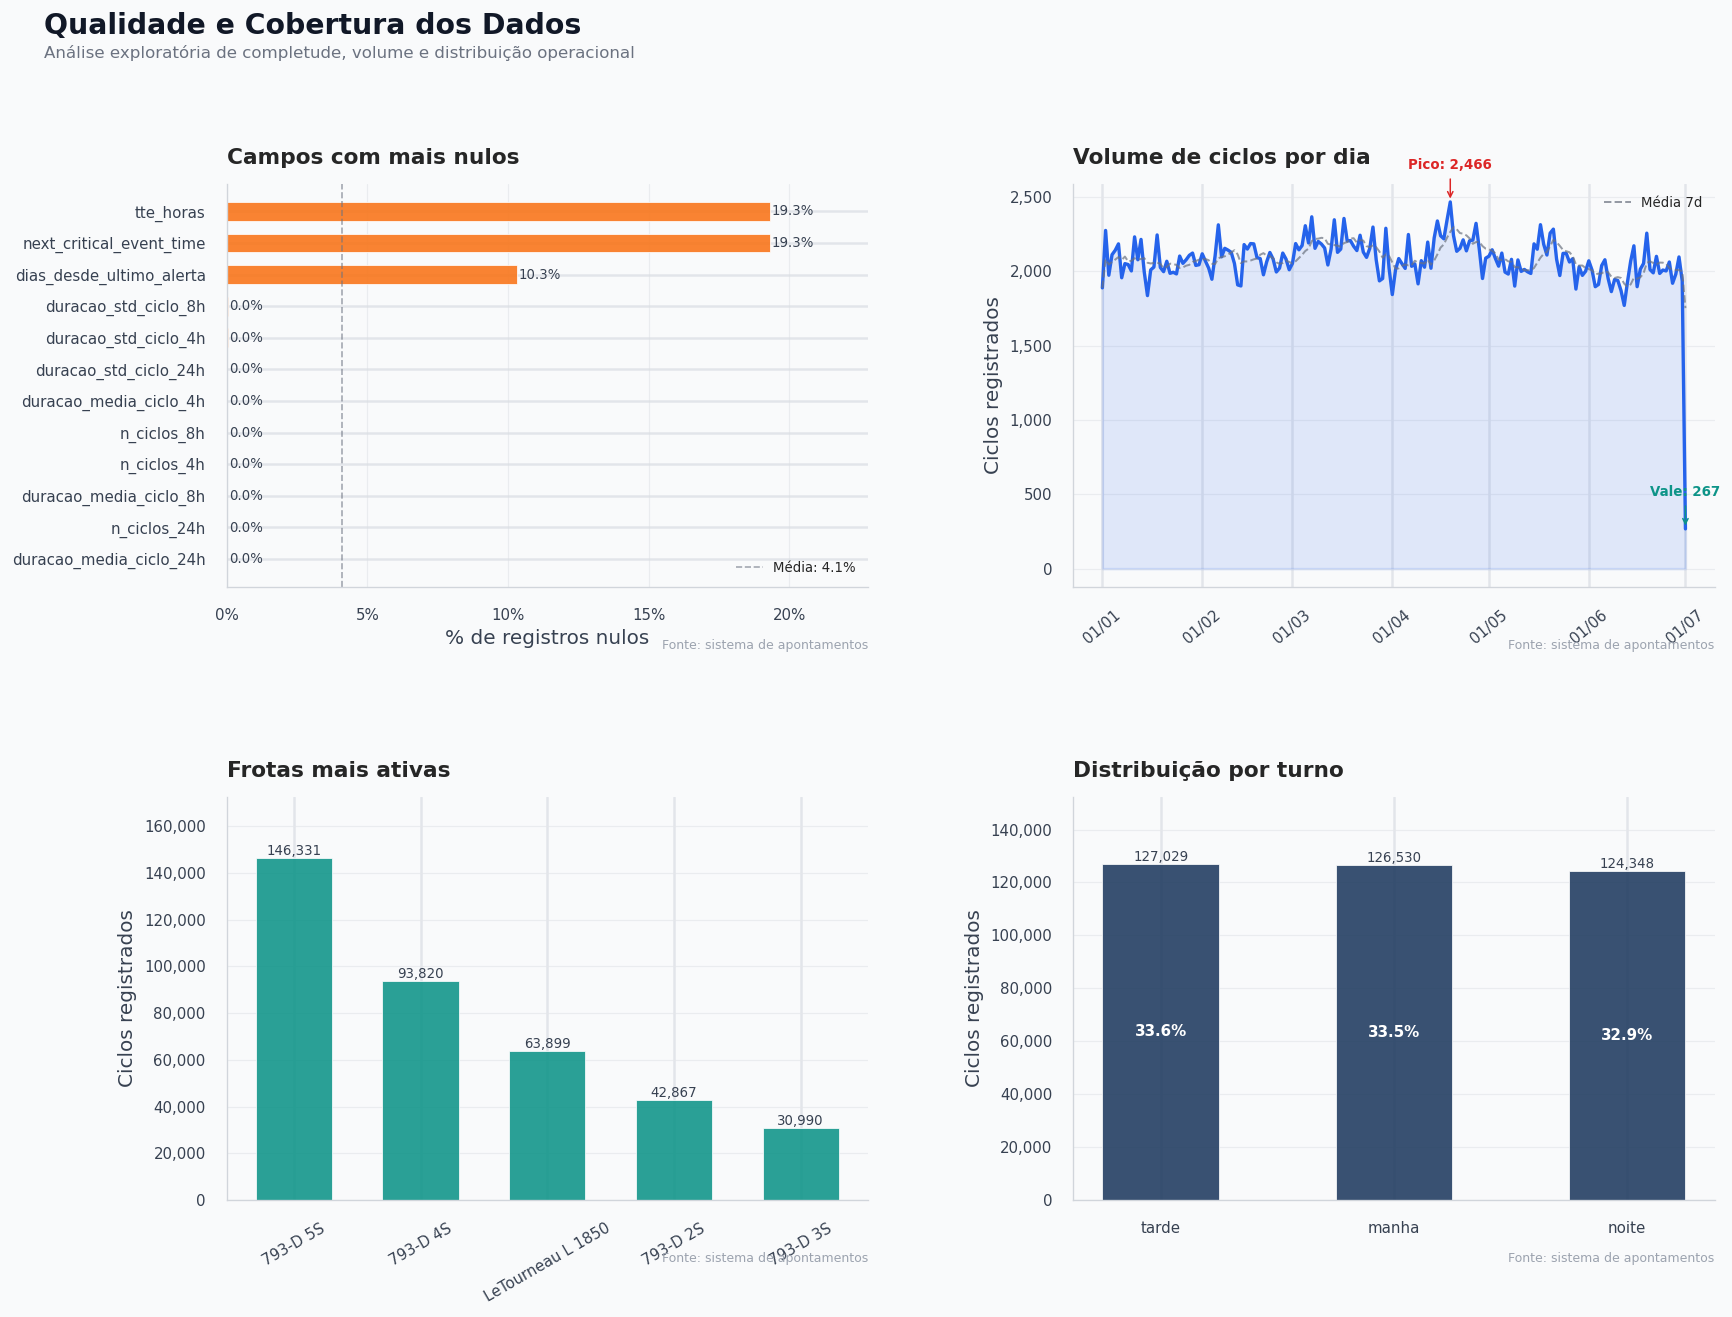

In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# ── helpers ────────────────────────────────────────────────────────────────────
def style_ax(ax, title, subtitle, source_note="Fonte: sistema de apontamentos"):
    ax.set_title(title, fontsize=13, fontweight="bold", loc="left", pad=12)
    ax.text(0, 1.035, subtitle, transform=ax.transAxes,
            fontsize=9.5, color="#6B7280", va="bottom")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#D1D5DB")
    ax.tick_params(colors="#374151", labelsize=9)
    ax.xaxis.label.set_color("#374151")
    ax.yaxis.label.set_color("#374151")
    ax.text(1, -0.13, source_note, transform=ax.transAxes,
            fontsize=7.5, color="#9CA3AF", ha="right", va="top")

def add_bar_labels_h(ax, bars, fmt="{:.1f}%", pad=0.3):
    xlim = ax.get_xlim()[1]
    for bar in bars:
        w = bar.get_width()
        ax.text(w + pad * 0.01 * xlim,
                bar.get_y() + bar.get_height() / 2,
                fmt.format(w), va="center", ha="left",
                fontsize=8, color="#374151")

def add_bar_labels_v(ax, bars, fmt="{:,.0f}", pad=5):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + pad,
                fmt.format(h), va="bottom", ha="center",
                fontsize=8, color="#374151")

# ── palette ────────────────────────────────────────────────────────────────────
P = {
    "orange": "#F97316", "blue": "#2563EB",
    "teal":   "#0D9488", "navy": "#1E3A5F",
    "red":    "#DC2626", "slate": "#6B7280",
    "bg":     "#F9FAFB",
}

# ── dados ──────────────────────────────────────────────────────────────────────
qc = features_df.copy()
qc["frota_decoded"] = decode_one_hot_prefix(qc, "Frota")
qc["tipo_decoded"]  = decode_one_hot_prefix(qc, "Tipo")
qc["turno"]         = qc["turno"].astype(str)

missing = (qc.isna().mean() * 100).sort_values(ascending=False).head(12)
vol_dia = qc.groupby(qc["Fim"].dt.date)["Id"].count()
vol_dia.index = pd.to_datetime(vol_dia.index)   # ← fix: date → datetime para mdates

# ── canvas ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11),
                         facecolor=P["bg"],
                         gridspec_kw={"hspace": 0.52, "wspace": 0.32})
fig.suptitle("Qualidade e Cobertura dos Dados",
             fontsize=17, fontweight="bold", x=0.03, ha="left",
             color="#111827", y=1.01)
fig.text(0.03, 0.985,
         "Análise exploratória de completude, volume e distribuição operacional",
         fontsize=10, color=P["slate"], ha="left", va="top")

for ax in axes.flat:
    ax.set_facecolor(P["bg"])

# ── [0,0] Nulos ────────────────────────────────────────────────────────────────
ax = axes[0, 0]
mp = missing.sort_values(ascending=True)
bars = ax.barh(mp.index, mp.values,
               color=P["orange"], height=0.6, alpha=0.88,
               edgecolor="white", linewidth=0.5)
ax.axvline(mp.values.mean(), color=P["slate"], lw=1, ls="--", alpha=0.6,
           label=f"Média: {mp.values.mean():.1f}%")
ax.legend(fontsize=8, frameon=False)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.set_xlim(0, mp.values.max() * 1.18)
ax.xaxis.grid(True, color="#E5E7EB", linewidth=0.7, zorder=0)
add_bar_labels_h(ax, bars)
style_ax(ax, "Campos com mais nulos", "")
ax.set_xlabel("% de registros nulos")

# ── [0,1] Volume por dia ───────────────────────────────────────────────────────
ax = axes[0, 1]
ax.fill_between(vol_dia.index, vol_dia.values,
                color=P["blue"], alpha=0.12, zorder=1)
ax.plot(vol_dia.index, vol_dia.values,
        color=P["blue"], linewidth=2, zorder=2)
ax.yaxis.grid(True, color="#E5E7EB", linewidth=0.7, zorder=0)
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
ax.tick_params(axis="x", rotation=40, labelsize=8)

roll = vol_dia.rolling(7, min_periods=1).mean()
ax.plot(roll.index, roll.values, color=P["slate"],
        linewidth=1.2, ls="--", alpha=0.7, label="Média 7d")
ax.legend(fontsize=8, frameon=False)

for day, label, color in [
    (vol_dia.idxmax(), f"Pico: {vol_dia.max():,.0f}", P["red"]),
    (vol_dia.idxmin(), f"Vale: {vol_dia.min():,.0f}", P["teal"]),
]:
    ax.annotate(label,
                xy=(day, vol_dia.loc[day]),
                xytext=(0, 20), textcoords="offset points",
                ha="center", fontsize=8, color=color, fontweight="bold",
                arrowprops=dict(arrowstyle="->", color=color, lw=0.9))

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
style_ax(ax, "Volume de ciclos por dia", "")
ax.set_ylabel("Ciclos registrados")

# ── [1,0] Top frotas ──────────────────────────────────────────────────────────
ax = axes[1, 0]
top_frota = qc["frota_decoded"].value_counts().head(8)
bars = ax.bar(top_frota.index, top_frota.values,
              color=P["teal"], width=0.6, alpha=0.88,
              edgecolor="white", linewidth=0.5)
ax.yaxis.grid(True, color="#E5E7EB", linewidth=0.7, zorder=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_ylim(0, top_frota.values.max() * 1.18)
ax.tick_params(axis="x", rotation=30, labelsize=8.5)
add_bar_labels_v(ax, bars)
style_ax(ax, "Frotas mais ativas", "")
ax.set_ylabel("Ciclos registrados")
ax.set_xlabel("")

# ── [1,1] Turno ───────────────────────────────────────────────────────────────
ax = axes[1, 1]
turno_counts = qc["turno"].value_counts()
bars = ax.bar(turno_counts.index, turno_counts.values,
              color=P["navy"], width=0.5, alpha=0.88,
              edgecolor="white", linewidth=0.5)
ax.yaxis.grid(True, color="#E5E7EB", linewidth=0.7, zorder=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_ylim(0, turno_counts.values.max() * 1.2)
ax.tick_params(axis="x", rotation=0, labelsize=9.5)
add_bar_labels_v(ax, bars)

for bar, val in zip(bars, turno_counts.values):
    share = val / turno_counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 0.5,
            f"{share:.1f}%", ha="center", va="center",
            fontsize=9, fontweight="bold", color="white")

style_ax(ax, "Distribuição por turno", "")
ax.set_ylabel("Ciclos registrados")

plt.savefig("qc_dashboard.png", dpi=150, bbox_inches="tight",
            facecolor=P["bg"], edgecolor="none")
plt.show()

## 3. Análise Exploratória Visual

Esta seção responde: **os dados têm sinal suficiente para prever falhas?**

Três análises são apresentadas:
1. **Distribuição de alertas por turno e frota** — onde os alertas se concentram
2. **Prevalência temporal (média móvel 7 dias)** — o target varia ao longo do tempo?
3. **Correlação entre variáveis-chave** — quais sinais estão mais associados à falha?

> Se as correlações são fracas e a prevalência é aleatória no tempo, o problema
> não é modelável. Os gráficos abaixo demonstram o contrário.


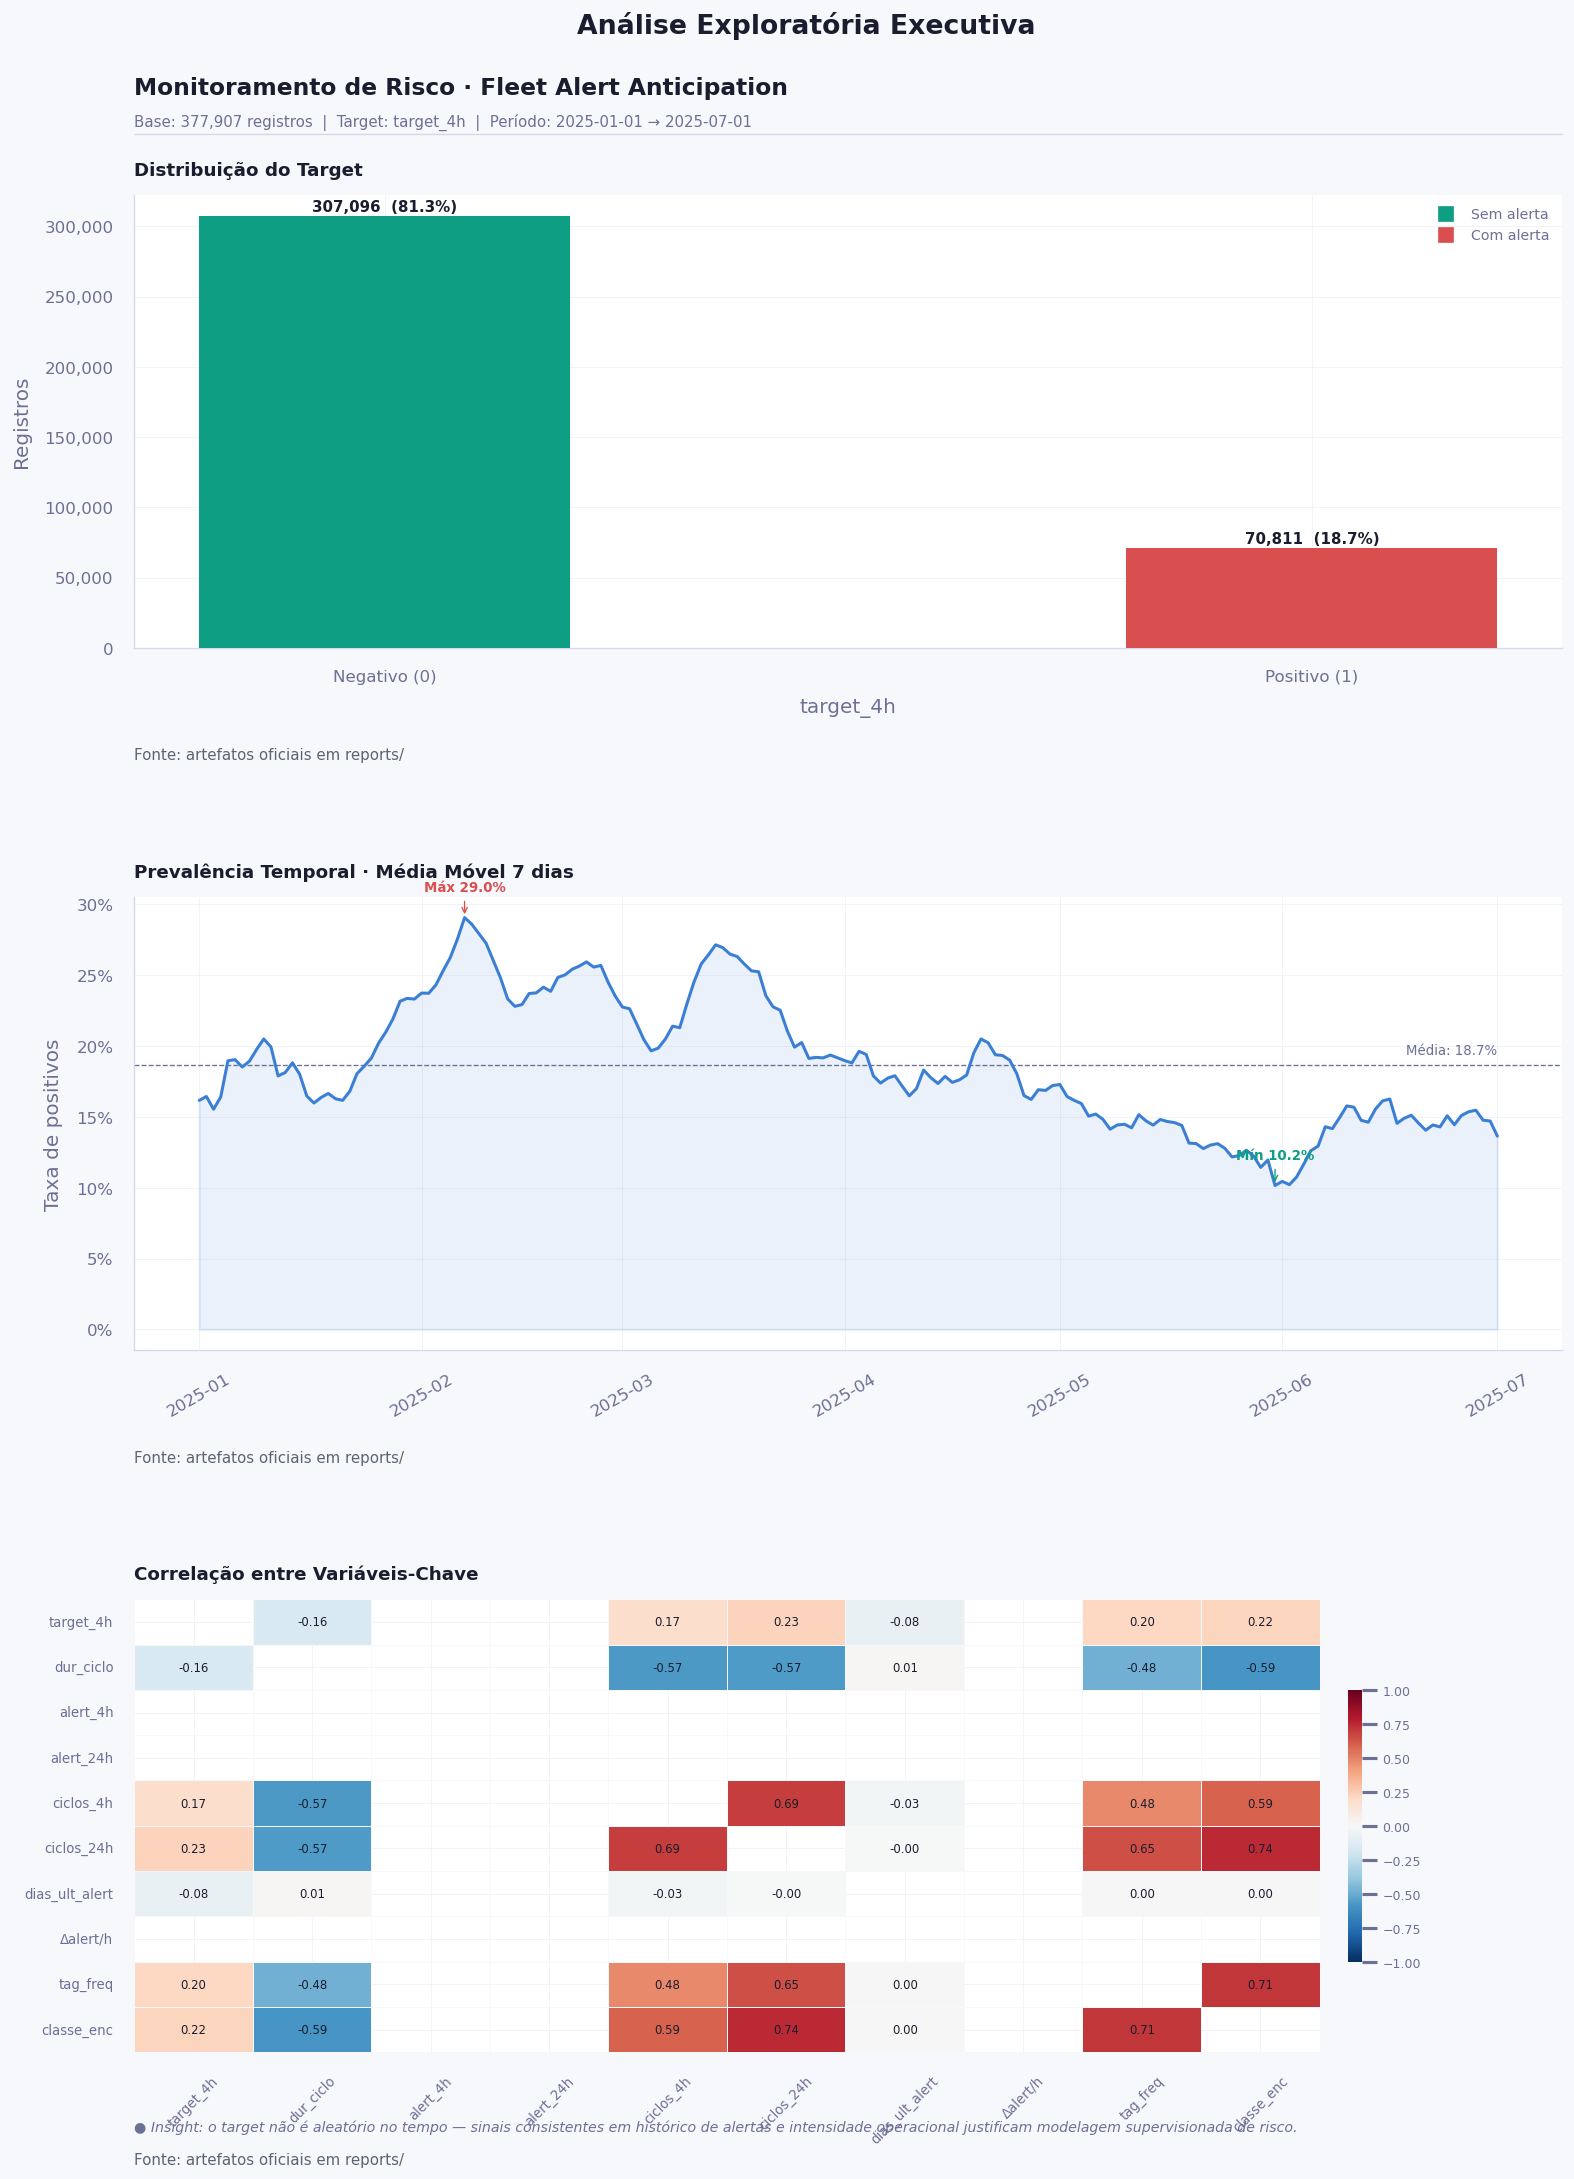

**Insight + implicação operacional:** a EDA mostra sinal temporal e operacional suficiente para justificar modelagem supervisionada, com foco em histórico recente de alertas e intensidade de uso.

In [18]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import seaborn as sns
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

EXEC = {
    'bg':        '#F7F8FC',
    'panel':     '#FFFFFF',
    'grid':      '#EAECF4',
    'border':    '#D5D8E8',
    'text':      '#1A1D2E',
    'muted':     '#6B7094',
    'teal':      '#0E9E84',
    'red':       '#D94F4F',
    'blue':      '#3A7FD5',
    'blue_fill': '#3A7FD520',
    'divider':   '#D5D8E8',
}

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.facecolor':    EXEC['panel'],
    'figure.facecolor':  EXEC['bg'],
    'axes.edgecolor':    EXEC['border'],
    'axes.labelcolor':   EXEC['muted'],
    'xtick.color':       EXEC['muted'],
    'ytick.color':       EXEC['muted'],
    'axes.grid':         True,
    'grid.color':        EXEC['grid'],
    'grid.linewidth':    0.5,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'text.color':        EXEC['text'],
})

eda = features_df.copy()
eda['dia'] = eda['Fim'].dt.date

fig = plt.figure(figsize=(14, 18), facecolor=EXEC['bg'])
fig.subplots_adjust(left=0.10, right=0.95, top=0.91, bottom=0.05, hspace=0.55)
fig.suptitle('Análise Exploratória Executiva', fontsize=16, fontweight='bold', y=0.995, color=EXEC['text'])

gs = gridspec.GridSpec(3, 1, figure=fig)
axes = [fig.add_subplot(gs[i]) for i in range(3)]

fig.text(0.10, 0.965,
         'Monitoramento de Risco · Fleet Alert Anticipation',
         fontsize=14, fontweight='bold', color=EXEC['text'], va='top')

fig.text(0.10, 0.948,
         f"Base: {len(eda):,} registros  |  Target: target_4h  |  "
         f"Período: {eda['dia'].min()} → {eda['dia'].max()}",
         fontsize=9, color=EXEC['muted'], va='top')

divider = Line2D([0.10, 0.95], [0.938, 0.938],
                 transform=fig.transFigure,
                 color=EXEC['border'], linewidth=0.8, clip_on=False)
fig.add_artist(divider)

ax = axes[0]
counts = eda['target_4h'].value_counts().sort_index()
colors = [EXEC['teal'], EXEC['red']]
bars = ax.bar(counts.index, counts.values,
              color=colors, width=0.4, zorder=3, linewidth=0)

total = counts.sum()
for bar, (label, val) in zip(bars, counts.items()):
    pct = val / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total * 0.005,
            f'{val:,}  ({pct:.1f}%)',
            ha='center', va='bottom',
            fontsize=9, color=EXEC['text'], fontweight='bold')

ax.set_title('Distribuição do Target',
             fontsize=11, fontweight='bold',
             color=EXEC['text'], pad=12, loc='left')
ax.set_xlabel('target_4h', labelpad=8)
ax.set_ylabel('Registros', labelpad=8)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Negativo (0)', 'Positivo (1)'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(handles=[
    Line2D([0], [0], color=EXEC['teal'], lw=0, marker='s', markersize=8, label='Sem alerta'),
    Line2D([0], [0], color=EXEC['red'], lw=0, marker='s', markersize=8, label='Com alerta'),
], fontsize=8.5, frameon=False, labelcolor=EXEC['muted'], loc='upper right')
add_source_note(ax)

for spine in ax.spines.values():
    spine.set_edgecolor(EXEC['border'])
    spine.set_linewidth(0.8)

ax = axes[1]
daily_prev = (eda.groupby('dia')['target_4h']
                 .mean()
                 .rolling(7, min_periods=1)
                 .mean())

x = daily_prev.index
y = daily_prev.values

ax.plot(x, y, color=EXEC['blue'], linewidth=1.8, zorder=3)
ax.fill_between(x, y, alpha=0.10, color=EXEC['blue'], zorder=2)

mean_val = y.mean()
ax.axhline(mean_val, color=EXEC['muted'], linewidth=0.8, linestyle='--', zorder=1)
ax.text(x[-1], mean_val + (y.max() - y.min()) * 0.03,
        f'Média: {mean_val:.1%}',
        ha='right', va='bottom', fontsize=8, color=EXEC['muted'])

idx_max = daily_prev.idxmax()
idx_min = daily_prev.idxmin()
for idx, label, color in [
    (idx_max, f'Máx {daily_prev[idx_max]:.1%}', EXEC['red']),
    (idx_min, f'Mín {daily_prev[idx_min]:.1%}', EXEC['teal']),
]:
    ax.annotate(label,
                xy=(idx, daily_prev[idx]),
                xytext=(0, 16), textcoords='offset points',
                ha='center', fontsize=8,
                color=color, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=color, lw=0.8))

ax.set_title('Prevalência Temporal · Média Móvel 7 dias',
             fontsize=11, fontweight='bold',
             color=EXEC['text'], pad=12, loc='left')
ax.set_ylabel('Taxa de positivos', labelpad=8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
ax.tick_params(axis='x', rotation=30)
add_source_note(ax)

for spine in ax.spines.values():
    spine.set_edgecolor(EXEC['border'])
    spine.set_linewidth(0.8)

ax = axes[2]
corr_cols = [
    'target_4h', 'duracao_ciclo_min', 'n_alertas_4h', 'n_alertas_24h',
    'n_ciclos_4h', 'n_ciclos_24h', 'dias_desde_ultimo_alerta',
    'delta_alertas_por_hora_4h_24h', 'Tag_freq', 'Classe_target_enc'
]
sub = eda[corr_cols].sample(min(30_000, len(eda)), random_state=42)
corr = sub.corr(numeric_only=True)

labels_curtos = [
    'target_4h', 'dur_ciclo', 'alert_4h', 'alert_24h',
    'ciclos_4h', 'ciclos_24h', 'dias_ult_alert',
    'Δalert/h', 'tag_freq', 'classe_enc'
]

mask = np.eye(len(corr), dtype=bool)
sns.heatmap(
    corr, mask=mask,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f',
    annot_kws={'size': 7, 'color': EXEC['text']},
    linewidths=0.4, linecolor=EXEC['bg'],
    xticklabels=labels_curtos,
    yticklabels=labels_curtos,
    cbar=True, cbar_kws={'shrink': 0.6, 'pad': 0.02},
    ax=ax
)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(colors=EXEC['muted'], labelsize=7.5)
cbar.outline.set_edgecolor(EXEC['border'])

ax.set_title('Correlação entre Variáveis-Chave',
             fontsize=11, fontweight='bold',
             color=EXEC['text'], pad=12, loc='left')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
add_source_note(ax)

fig.text(
    0.10, 0.012,
    '● Insight: o target não é aleatório no tempo — sinais consistentes em '
    'histórico de alertas e intensidade operacional justificam modelagem '
    'supervisionada de risco.',
    fontsize=8.5, color=EXEC['muted'], va='bottom', style='italic'
)

plt.savefig(REPORTS / 'eda_executivo.png', dpi=150, bbox_inches='tight', facecolor=EXEC['bg'])
plt.show()

display(Markdown(
    '**Insight + implicação operacional:** a EDA mostra sinal temporal e operacional suficiente para justificar modelagem supervisionada, com foco em histórico recente de alertas e intensidade de uso.'
))


## 4. Preparação e Feature Engineering

O modelo não usa dados brutos diretamente. Antes, construímos **features de negócio**
que capturam o contexto operacional de cada equipamento.

### Lógica das famílias de features

| Família | O que representa |
|---|---|
| **Temporais** | Hora do dia, turno, fim de semana — contexto de operação |
| **Alertas rolling** | Quantidade de alertas nas últimas 4h e 24h — deterioração recente |
| **Ciclos rolling** | Padrões de uso e duração dos ciclos — comportamento operacional |
| **Mudança/degradação** | Variação entre janelas de tempo — aceleração do problema |
| **Codificação categórica** | Risco histórico por equipamento, frota e classe de atividade |

A tabela abaixo mostra a quantidade de variáveis em cada família e um exemplo
das features mais relevantes.


In [19]:
all_cols = features_df.columns.tolist()

families = {
    'Temporais': [c for c in all_cols if c in {'hora_do_dia','dia_da_semana','mes','turno','is_fim_de_semana','duracao_ciclo_min'}],
    'Alertas rolling': [c for c in all_cols if c.startswith('n_alertas_') or c.startswith('alertas_por_hora_')],
    'Ciclos rolling': [c for c in all_cols if c.startswith('n_ciclos_') or c.startswith('duracao_media_ciclo_') or c.startswith('duracao_std_ciclo_')],
    'Mudança/degradação': [c for c in all_cols if c.startswith('delta_') or c.startswith('ratio_')],
    'Codificação categórica': [c for c in all_cols if c.endswith('_freq') or c.endswith('_target_enc') or c.startswith('Frota_') or c.startswith('Tipo_')],
}

family_df = pd.DataFrame(
    {'Família': list(families.keys()), 'Quantidade de features': [len(v) for v in families.values()]}
).sort_values('Quantidade de features', ascending=False)

display(family_df.style.bar(subset='Quantidade de features', color='#4472C4'))

example_cols = [
    'n_alertas_4h', 'n_alertas_24h', 'n_ciclos_4h', 'duracao_media_ciclo_24h',
    'delta_alertas_por_hora_4h_24h', 'Tag_freq', 'Classe_target_enc'
]
display(
    features_df[example_cols + ['target_4h']].head(8).style
    .highlight_max(subset=['target_4h'], color='#fff3cd')
    .format({'target_4h': '{:.0f}'})
)

display(Markdown(
    '**Insight + implicação operacional:** as features capturam contexto temporal, histórico e mudança de comportamento da operação, o que permite priorização mais robusta por equipamento.'
))


,Família,Quantidade de features
4,Codificação categórica,10
2,Ciclos rolling,9
3,Mudança/degradação,7
0,Temporais,6
1,Alertas rolling,6


,n_alertas_4h,n_alertas_24h,n_ciclos_4h,duracao_media_ciclo_24h,delta_alertas_por_hora_4h_24h,Tag_freq,Classe_target_enc,target_4h
0,0,0,nan,nan,0.000000,0.008812,0.357143,0
1,0,0,1.000000,60.000000,0.000000,0.008812,0.274510,0
2,0,0,2.000000,60.000000,0.000000,0.008812,0.267606,0
3,0,0,3.000000,60.000000,0.000000,0.008812,0.250000,0
4,0,0,4.000000,60.000000,0.000000,0.008812,0.203252,0
5,0,0,4.000000,60.000000,0.000000,0.008812,0.185430,0
6,0,0,4.000000,60.000000,0.000000,0.008812,0.182692,0
7,0,0,4.000000,60.000000,0.000000,0.008812,0.159363,0


**Insight + implicação operacional:** as features capturam contexto temporal, histórico e mudança de comportamento da operação, o que permite priorização mais robusta por equipamento.

## 5. Benchmark de Candidatos

Testamos múltiplos algoritmos com a **mesma metodologia operacional**: split temporal
(70/15/15), sem vazamento de dados, avaliação por TopK Tag-dia (não por ciclo isolado).

### Critério de seleção técnica

O modelo selecionado no benchmark foi definido por:
1. **Maior `Recall@Top15` na validação** — capturar o máximo de falhas reais
2. Desempate por `Precision@15`, `Lift@15` e `AUC-PR`

> Por que Recall primeiro? Em manutenção preventiva, **perder uma falha real** (falso
> negativo) é mais custoso do que inspecionar um equipamento saudável (falso positivo).
> A estratégia TopK controla o volume de inspeções, tornando o custo de FP gerenciável.

O gráfico e a tabela abaixo mostram o desempenho de todos os candidatos.


,model_name,Val Precision@15,Val Recall@15,Val Lift@15,Test Precision@15,Test Recall@15,Test Lift@15,Val AUC-PR
0,hist_gbdt_balanced,0.6619,0.7493,2.1231,0.6822,0.7433,2.0979,0.2523
1,hist_gbdt_regularized,0.6548,0.7412,2.1002,0.6689,0.7288,2.0569,0.2890
2,lightgbm_balanced,0.6524,0.7385,2.0925,0.6756,0.7361,2.0774,0.2498
3,logistic_regression_balanced,0.6238,0.7062,2.0009,0.6733,0.7337,2.0705,0.2344
4,extra_trees_balanced,0.6238,0.7062,2.0009,0.6578,0.7167,2.0227,0.2232
5,random_forest_balanced,0.6214,0.7035,1.9933,0.6689,0.7288,2.0569,0.2390


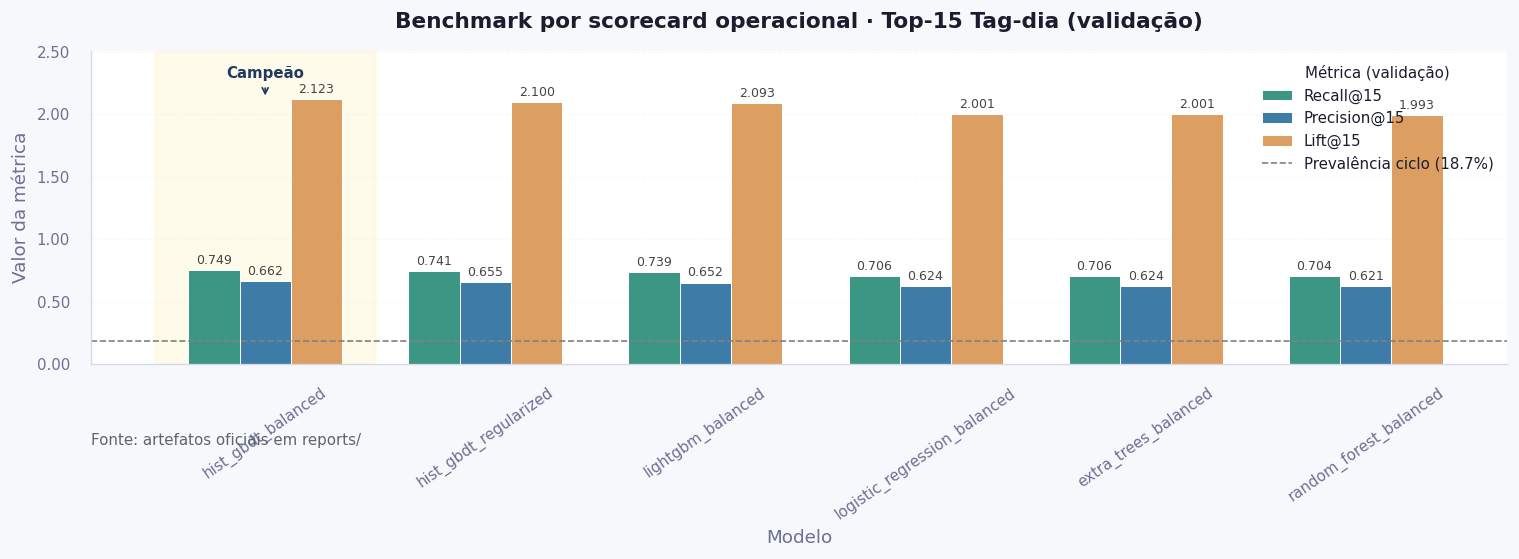

**Insight + implicação operacional:** o modelo campeão foi **`hist_gbdt_balanced`**, com **Recall@Top15 = `0.7493`** na validação — captura 74.9% dos positivos verdadeiros dentro dos 15 primeiros. A **Precision@15 = `0.6619`** e o **Lift@15 = `2.12×`** confirmam ganho expressivo sobre amostragem aleatória. O AUC-PR (`0.2523`) serve como diagnóstico técnico auxiliar de discriminação global.

In [20]:
bench_cols = [
    'model_name',
    'val_top15_precision_at_k',
    'val_top15_recall_at_k',
    'val_top15_lift_vs_random',
    'test_top15_precision_at_k',
    'test_top15_recall_at_k',
    'test_top15_lift_vs_random',
    'val_auc_pr',
]

bench = benchmark_df[bench_cols].copy()
bench = bench.sort_values(
    ['val_top15_recall_at_k', 'val_top15_precision_at_k', 'val_top15_lift_vs_random', 'val_auc_pr'],
    ascending=False,
)

rename_cols = {
    'val_top15_precision_at_k': 'Val Precision@15',
    'val_top15_recall_at_k': 'Val Recall@15',
    'val_top15_lift_vs_random': 'Val Lift@15',
    'test_top15_precision_at_k': 'Test Precision@15',
    'test_top15_recall_at_k': 'Test Recall@15',
    'test_top15_lift_vs_random': 'Test Lift@15',
    'val_auc_pr': 'Val AUC-PR',
}

display(bench.rename(columns=rename_cols).style.format(precision=4))

metric_map = {
    'val_top15_recall_at_k': ('Recall@15', PALETTE['teal']),
    'val_top15_precision_at_k': ('Precision@15', PALETTE['blue']),
    'val_top15_lift_vs_random': ('Lift@15', PALETTE['orange']),
}

plot_df = bench.melt(
    id_vars='model_name',
    value_vars=list(metric_map.keys()),
    var_name='metric_key',
    value_name='Valor',
)
plot_df['Métrica'] = plot_df['metric_key'].map({k: v[0] for k, v in metric_map.items()})
palette = {v[0]: v[1] for v in metric_map.values()}
order = bench['model_name'].tolist()
base_rate = features_df['target_4h'].mean()

fig, ax = plt.subplots(figsize=(13, 5))

sns.barplot(
    data=plot_df,
    x='model_name',
    y='Valor',
    hue='Métrica',
    palette=palette,
    order=order,
    ax=ax,
    width=0.7,
    edgecolor='white',
    linewidth=0.6,
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', label_type='edge', fontsize=7.5, padding=2, color='#444')

ax.axhline(y=base_rate, color='grey', lw=1, ls='--', label=f'Prevalência ciclo ({base_rate:.1%})')

idx_winner = order.index(winner_name)
max_val = plot_df.loc[plot_df['model_name'] == winner_name, 'Valor'].max()
ax.axvspan(idx_winner - 0.5, idx_winner + 0.5, color='gold', alpha=0.08, zorder=0)
ax.annotate(
    'Selecionado',
    xy=(idx_winner, max_val),
    xytext=(idx_winner, max_val * 1.08),
    ha='center',
    fontsize=9,
    fontweight='bold',
    color=PALETTE['navy'],
    arrowprops=dict(arrowstyle='->', color=PALETTE['navy'], lw=1),
)

ax.set_title('Benchmark por scorecard operacional · Top-15 Tag-dia (validação)', fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Modelo', fontsize=11)
ax.set_ylabel('Valor da métrica', fontsize=11)
ax.tick_params(axis='x', rotation=35, labelsize=9)
ax.tick_params(axis='y', labelsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
ax.set_ylim(0, plot_df['Valor'].max() * 1.18)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.35, linestyle='--', lw=0.7)
ax.legend(title='Métrica (validação)', title_fontsize=9, fontsize=9, framealpha=0.6)

add_source_note(ax)
plt.tight_layout()
plt.show()

display(Markdown(
    f"**Insight + implicação operacional:** o modelo selecionado foi **`{winner_name}`**, "
    f"com **Recall@Top15 = `{winner_val_recall_top15:.4f}`** na validação — "
    f"captura {winner_val_recall_top15:.1%} dos positivos verdadeiros dentro dos 15 primeiros. "
    f"A **Precision@15 = `{winner_val_precision_top15:.4f}`** e o "
    f"**Lift@15 = `{winner_val_lift_top15:.2f}×`** confirmam ganho expressivo sobre amostragem aleatória. "
    f"O AUC-PR (`{winner_val_auc_pr:.4f}`) serve como diagnóstico técnico auxiliar de discriminação global."
))


## 6. Modelo Selecionado e Threshold Operacional

O modelo selecionado no benchmark técnico alimenta a etapa operacional.

### O que é o threshold?

O modelo gera um **score de risco** entre 0 e 1 para cada equipamento em cada
ciclo. O threshold (`0.1414`) é o valor de corte acima do qual o modelo classifica
o equipamento como "em risco" no ciclo.

**Importante:** na operação real, usamos a estratégia **TopK Tag-dia** — os 15
equipamentos com maior score diário entram na fila, independentemente do threshold.
O threshold é usado apenas para diagnóstico técnico de ciclo-a-ciclo.

### Como ler a matriz de confusão

| | Predito: Sem falha | Predito: Com falha |
|---|---|---|
| **Real: Sem falha** | ✅ Verdadeiro Negativo (TN) | ⚠️ Falso Positivo (FP) |
| **Real: Com falha** | ❌ Falso Negativo (FN) | ✅ Verdadeiro Positivo (TP) |

Os gráficos abaixo mostram o trade-off recall/precision por threshold e a matriz
de confusão no conjunto de teste com o threshold operacional calibrado.


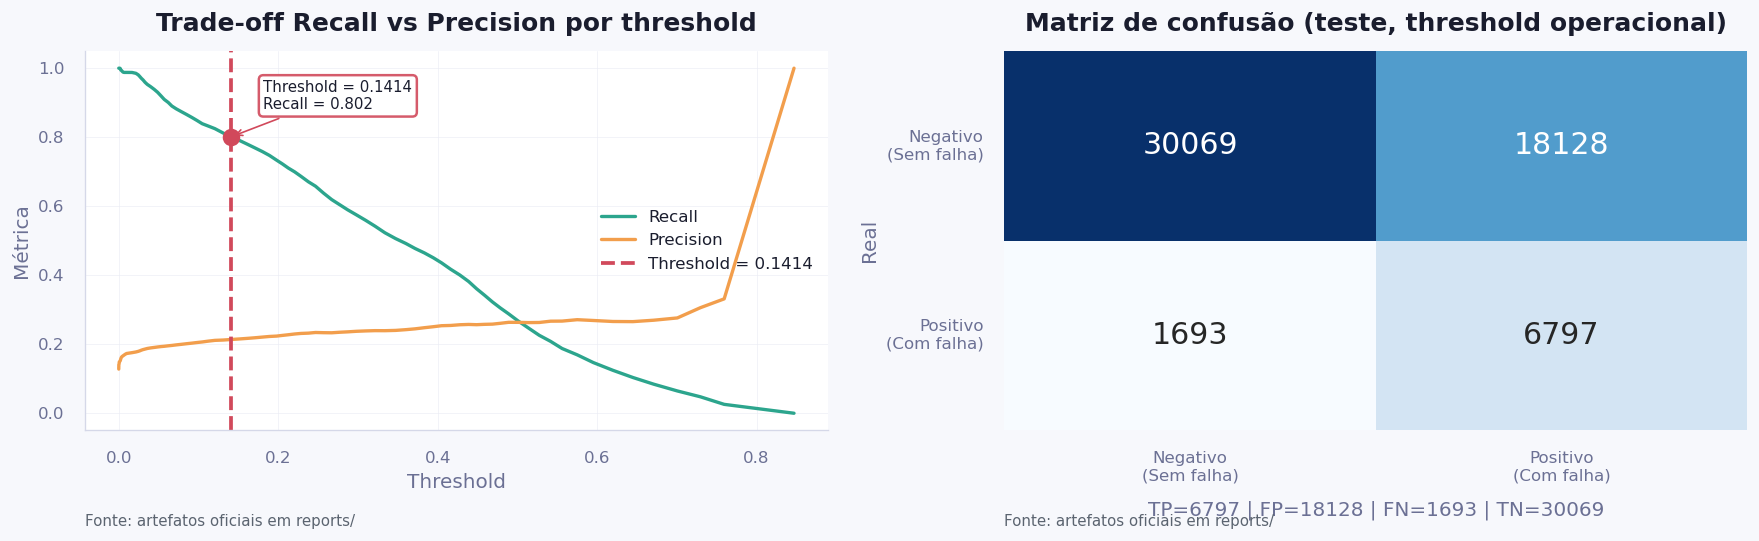

**Insight + implicação operacional:** com threshold `0.1414`, o modelo mantém recall alto (`0.801`) como diagnóstico técnico; no dia a dia, a decisão permanece ancorada no ranking Top15 Tag-dia.

In [21]:
threshold = threshold_test['threshold']
curve = threshold_curve_df.copy()
closest_idx = (curve['threshold'] - threshold).abs().idxmin()
selected = curve.loc[closest_idx]
recall_val = selected['recall']
precision_val = selected['precision']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(curve['threshold'], curve['recall'], label='Recall', color=PALETTE['teal'], linewidth=2)
ax.plot(curve['threshold'], curve['precision'], label='Precision', color=PALETTE['orange'], linewidth=2)
ax.axvline(threshold, color=PALETTE['red'], linestyle='--', label=f'Threshold = {threshold:.4f}')
ax.scatter([threshold], [recall_val], color=PALETTE['red'], zorder=4)
ax.annotate(
    f'Threshold = {threshold:.4f}\nRecall = {recall_val:.3f}',
    xy=(threshold, recall_val),
    xytext=(threshold + 0.04, min(recall_val + 0.08, 0.98)),
    fontsize=9,
    bbox=dict(boxstyle='round', fc='white', ec=PALETTE['red'], alpha=0.9),
    arrowprops=dict(arrowstyle='->', color=PALETTE['red'], lw=1),
)
ax.set_title('Trade-off Recall vs Precision por threshold')
ax.set_xlabel('Threshold')
ax.set_ylabel('Métrica')
ax.legend()
add_source_note(ax)

ax = axes[1]
rows = int(threshold_test['rows'])
tp = int(threshold_test['true_positive'])
fp = int(threshold_test['false_positive'])
fn = int(threshold_test['false_negative'])
tn = rows - tp - fp - fn
cm = np.array([[tn, fp], [fn, tp]])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
ax.set_title('Matriz de confusão (teste, threshold operacional)')
ax.set_xlabel(f'TP={tp} | FP={fp} | FN={fn} | TN={tn}', labelpad=10)
ax.set_ylabel('Real')
ax.set_xticklabels(['Negativo\n(Sem falha)', 'Positivo\n(Com falha)'])
ax.set_yticklabels(['Negativo\n(Sem falha)', 'Positivo\n(Com falha)'], rotation=0)
add_source_note(ax)

plt.tight_layout()
plt.show()

display(Markdown(
    f"**Insight + implicação operacional:** com threshold `{threshold:.4f}`, o modelo mantém recall alto (`{threshold_test['recall']:.3f}`) como diagnóstico técnico; no dia a dia, a decisão permanece ancorada no ranking Top15 Tag-dia."
))


## 7. Explicação do Modelo — O Que Guia as Previsões?

Para confiar e auditar o modelo, precisamos entender quais variáveis influenciam
mais as suas decisões.

> **Importante:** importância de feature em Gradient Boosting indica o quanto
> cada variável contribuiu para reduzir o erro durante o treino — não é causalidade,
> mas é um bom proxy de relevância operacional.

As variáveis mais importantes estão ligadas a **histórico recente de alertas e
intensidade operacional** — o que é intuitivo: equipamentos que acumularam muitos
alertas nas últimas horas têm maior probabilidade de falhar nas próximas 4h.

A tabela abaixo traduz cada feature técnica para a linguagem de negócio.


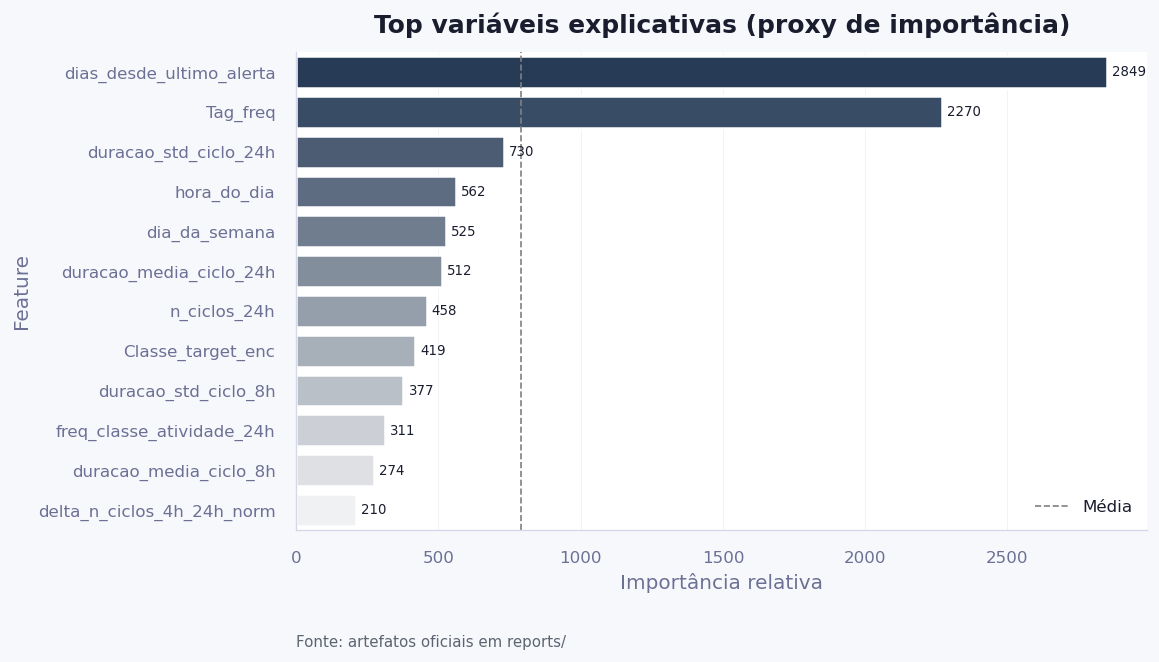

,feature,Leitura de negócio
0,dias_desde_ultimo_alerta,Recência de evento crítico anterior.
1,Tag_freq,Comportamento histórico da tag no conjunto.
2,duracao_std_ciclo_24h,Variável técnica de apoio ao ranking de risco.
3,hora_do_dia,Variável técnica de apoio ao ranking de risco.
4,dia_da_semana,Variável técnica de apoio ao ranking de risco.
5,duracao_media_ciclo_24h,Variável técnica de apoio ao ranking de risco.
6,n_ciclos_24h,Variável técnica de apoio ao ranking de risco.
7,Classe_target_enc,Risco histórico associado à classe de atividade.
8,duracao_std_ciclo_8h,Variável técnica de apoio ao ranking de risco.
9,freq_classe_atividade_24h,Variável técnica de apoio ao ranking de risco.


**Insight + implicação operacional:** os principais sinais estão ligados a histórico e aceleração de alertas; isso permite justificar ações preventivas com base em evidência de comportamento operacional.

In [22]:
imp = feature_importance_df.copy().head(12)

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.light_palette(PALETTE['navy'], n_colors=len(imp), reverse=True)
sns.barplot(data=imp, y='feature', x='importance', palette=colors, hue='feature', dodge=False, legend=False, ax=ax)
ax.axvline(imp['importance'].mean(), color='grey', ls='--', lw=1, label='Média')
ax.set_title('Top variáveis explicativas (proxy de importância)')
ax.set_xlabel('Importância relativa')
ax.set_ylabel('Feature')
ax.legend()
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=8)
add_source_note(ax)
plt.tight_layout()
plt.show()

business_translation = {
    'n_alertas_24h': 'Histórico recente de alertas críticos do equipamento.',
    'n_alertas_4h': 'Sinal imediato de deterioração no curto prazo.',
    'alertas_por_hora_24h': 'Intensidade normalizada de alertas ao longo do dia.',
    'duracao_ciclo_min': 'Mudança no padrão operacional do ciclo.',
    'dias_desde_ultimo_alerta': 'Recência de evento crítico anterior.',
    'Tag_freq': 'Comportamento histórico da tag no conjunto.',
    'Classe_target_enc': 'Risco histórico associado à classe de atividade.',
}

translation_df = imp[['feature']].copy()
translation_df['Leitura de negócio'] = translation_df['feature'].map(business_translation).fillna(
    'Variável técnica de apoio ao ranking de risco.'
)
display(
    translation_df.style
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([{'selector': 'th', 'props': [('font-weight', 'bold')]}])
)

display(Markdown(
    '**Insight + implicação operacional:** os principais sinais estão ligados a histórico e aceleração de alertas; isso permite justificar ações preventivas com base em evidência de comportamento operacional.'
))


## 8. Avaliação Operacional — Top15 Tag-dia

Esta é a seção mais importante para a decisão de adoção do modelo.

### Como funciona a avaliação

A cada dia do conjunto de teste, o modelo produz um ranking de risco para todos
os equipamentos. Selecionamos os **15 primeiros (Top15)** e verificamos:
- Quantos deles realmente tiveram falha? → **Precision@15**
- Dos que realmente falhariam, quantos capturamos? → **Recall@15**
- Quantas vezes melhor que sortear aleatoriamente? → **Lift@15**

### Por que Top15?

O gráfico à esquerda mostra o trade-off entre o tamanho da lista e o desempenho.
Top15 foi escolhido por ser o **melhor ponto de equilíbrio** entre capacidade
operacional (número de inspeções por dia) e cobertura de falhas.

O gráfico à direita mostra o mesmo raciocínio por percentual de orçamento de alertas.


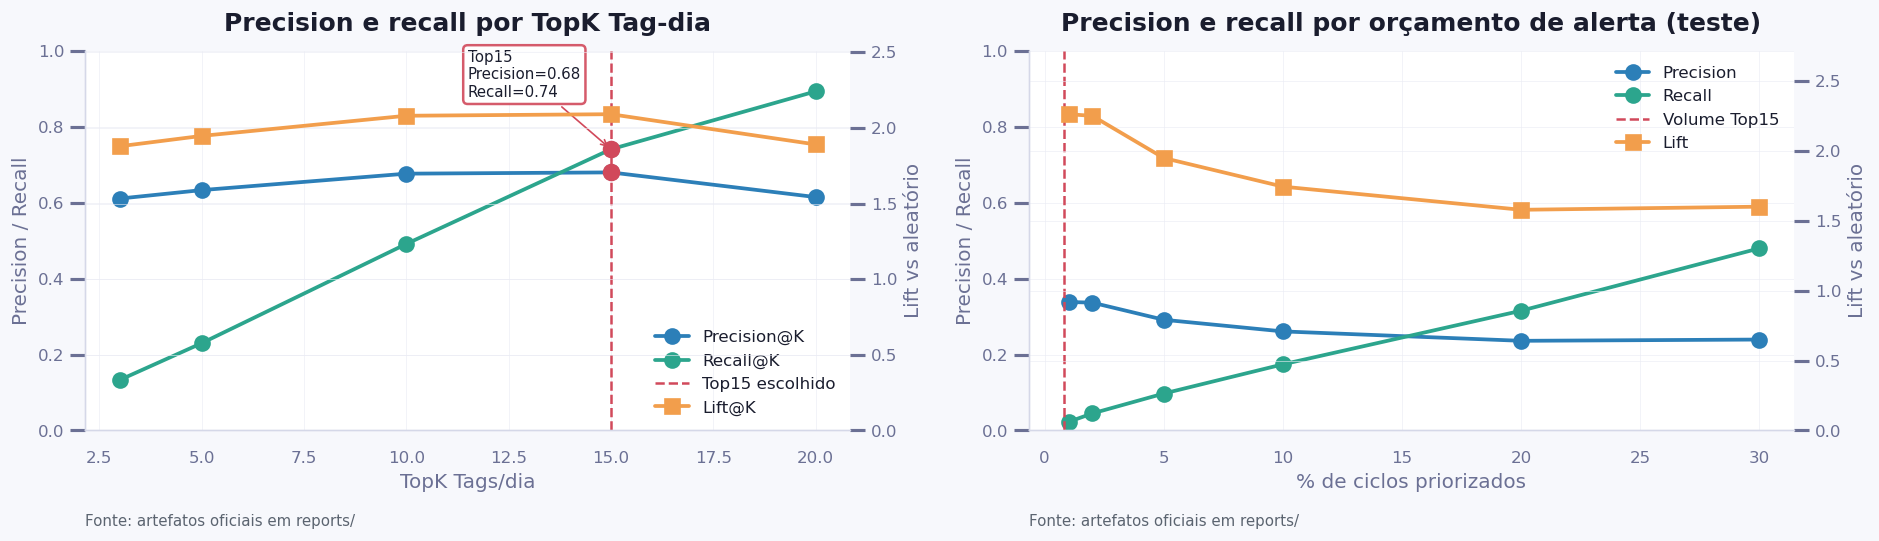

,TopK Tags/dia,Alertas/dia,Precision@K,Recall@K,Lift@K
0,3,3.0000,0.6111,0.1332,1.8792
1,5,5.0000,0.6333,0.2300,1.9475
2,10,10.0000,0.6767,0.4915,2.0808
3,15,15.0000,0.6800,0.7409,2.0910
4,20,20.0000,0.6150,0.8935,1.8912


**Insight + implicação operacional:** Top15 é o melhor ponto de equilíbrio: mantém Precision@15 em `0.680`, eleva Recall@15 para `0.741` e preserva Lift@15 de `2.09×`, sem expandir a rotina para Top20.

In [23]:
topk = oper_topk_df.query("split == 'test'").copy().sort_values('top_k_tags_per_day')
budget = oper_budget_df.query("split == 'test'").copy().sort_values('budget_pct')
top15_row = topk.loc[topk['top_k_tags_per_day'] == 15].iloc[0]
top15_cycle_budget = top15_row['selected_alerts'] / threshold_test['rows'] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(topk['top_k_tags_per_day'], topk['precision_at_k'], marker='o', color=PALETTE['blue'], label='Precision@K')
ax.plot(topk['top_k_tags_per_day'], topk['recall_at_k'], marker='o', color=PALETTE['teal'], label='Recall@K')
ax.axvline(15, color=PALETTE['red'], linestyle='--', linewidth=1.5, label='Top15 escolhido')
ax.scatter([15, 15], [top15_row['precision_at_k'], top15_row['recall_at_k']], color=PALETTE['red'], zorder=4)
ax.annotate(
    f"Top15\nPrecision={top15_row['precision_at_k']:.2f}\nRecall={top15_row['recall_at_k']:.2f}",
    xy=(15, top15_row['recall_at_k']),
    xytext=(11.5, 0.88),
    fontsize=9,
    bbox=dict(boxstyle='round', fc='white', ec=PALETTE['red'], alpha=0.9),
    arrowprops=dict(arrowstyle='->', color=PALETTE['red'], lw=1),
)
ax.set_title('Precision e recall por TopK Tag-dia')
ax.set_xlabel('TopK Tags/dia')
ax.set_ylabel('Precision / Recall')
ax.set_ylim(0, 1)

ax_lift = ax.twinx()
ax_lift.plot(topk['top_k_tags_per_day'], topk['lift_vs_random'], marker='s', color=PALETTE['orange'], label='Lift@K')
ax_lift.set_ylabel('Lift vs aleatório')
ax_lift.set_ylim(0, max(topk['lift_vs_random']) * 1.2)

lines, labels = ax.get_legend_handles_labels()
lift_lines, lift_labels = ax_lift.get_legend_handles_labels()
ax.legend(lines + lift_lines, labels + lift_labels, loc='lower right')
add_source_note(ax)

ax = axes[1]
ax.plot(budget['budget_pct'] * 100, budget['precision_at_budget'], marker='o', color=PALETTE['blue'], label='Precision')
ax.plot(budget['budget_pct'] * 100, budget['recall_at_budget'], marker='o', color=PALETTE['teal'], label='Recall')
ax.axvline(top15_cycle_budget, color=PALETTE['red'], linestyle='--', linewidth=1.5, label='Volume Top15')
ax.set_title('Precision e recall por orçamento de alerta (teste)')
ax.set_xlabel('% de ciclos priorizados')
ax.set_ylabel('Precision / Recall')
ax.set_ylim(0, 1)

ax_lift = ax.twinx()
ax_lift.plot(budget['budget_pct'] * 100, budget['lift_vs_random'], marker='s', color=PALETTE['orange'], label='Lift')
ax_lift.set_ylabel('Lift vs aleatório')
ax_lift.set_ylim(0, max(budget['lift_vs_random']) * 1.2)

lines, labels = ax.get_legend_handles_labels()
lift_lines, lift_labels = ax_lift.get_legend_handles_labels()
ax.legend(lines + lift_lines, labels + lift_labels, loc='upper right')
add_source_note(ax)

plt.tight_layout()
plt.show()

topk_table = topk[
    ['top_k_tags_per_day', 'alerts_per_day', 'precision_at_k', 'recall_at_k', 'lift_vs_random']
].rename(
    columns={
        'top_k_tags_per_day': 'TopK Tags/dia',
        'alerts_per_day': 'Alertas/dia',
        'precision_at_k': 'Precision@K',
        'recall_at_k': 'Recall@K',
        'lift_vs_random': 'Lift@K',
    }
)
display(
    topk_table.round(4).style
    .highlight_max(color='#d4edda')
    .highlight_min(color='#f8d7da')
    .format(precision=4)
)

display(Markdown(
    f"**Insight + implicação operacional:** Top15 é o melhor ponto de equilíbrio: "
    f"mantém Precision@15 em `{top15_row['precision_at_k']:.3f}`, "
    f"eleva Recall@15 para `{top15_row['recall_at_k']:.3f}` e preserva "
    f"Lift@15 de `{top15_row['lift_vs_random']:.2f}×`, sem expandir a rotina para Top20."
))


## 9. Análise de Segmentos e Riscos

O desempenho global esconde variações importantes entre grupos de equipamentos.
Esta seção responde: **o modelo é consistente entre frotas, tipos e turnos?**

### O que cada categoria significa

| Categoria | Definição | Ação recomendada |
|---|---|---|
| ✅ **Segmentos fortes** | Alto Recall@15 e Precision@15 | Operar com confiança total |
| ⚠️ **Segmentos frágeis** | Desempenho abaixo da meta | Revisão de features ou regras manuais complementares |
| ❓ **Segmentos inconclusivos** | Baixa prevalência — amostra insuficiente | Monitorar separadamente; não generalizar |

> **Política de governança:** segmentos inconclusivos por baixa prevalência não
> devem ser descartados — devem ser tratados com trilha dedicada de coleta de dados.


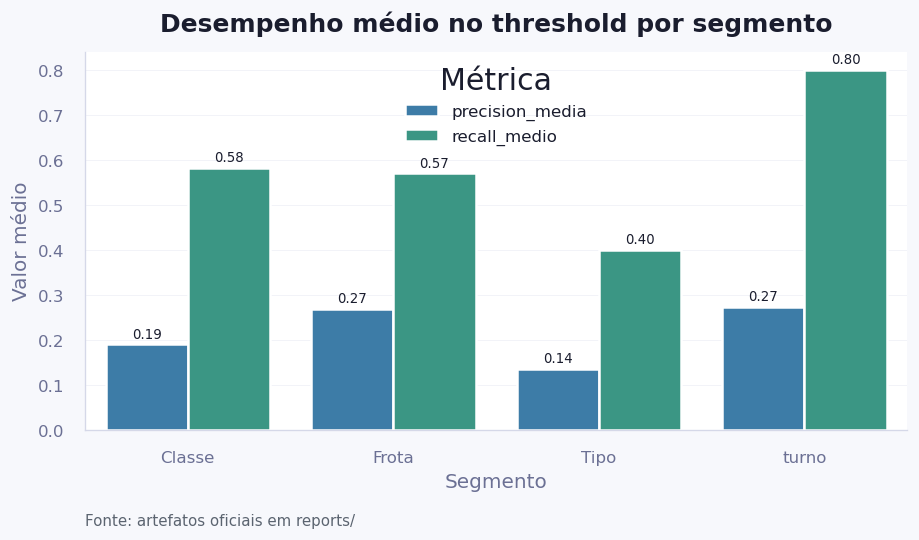

,segment_col,segment_value,top_k_tags_per_day,tag_days,days,selected_alerts,alerts_per_day,tag_day_prevalence,precision_at_k,recall_at_k,lift_vs_random,positives_captured,total_positives,status,recommendation
0,turno,manha,15,1185,28,420,15.000,0.200,0.469,0.831,2.345,197,237,ok,usar TopK como canal principal
1,turno,tarde,15,1227,29,435,15.000,0.200,0.437,0.776,2.187,190,245,ok,usar TopK como canal principal
2,turno,noite,15,1267,30,450,15.000,0.253,0.520,0.729,2.052,234,321,ok,usar TopK como canal principal
3,Tipo,Caminhao,15,999,30,450,15.000,0.411,0.680,0.745,1.653,306,411,ok,usar TopK como canal principal
4,Classe,Parado,15,784,30,450,15.000,0.477,0.651,0.783,1.365,293,374,ok,usar TopK como canal principal
5,Classe,Operando,15,793,30,450,15.000,0.499,0.676,0.768,1.353,304,396,ok,usar TopK como canal principal
6,Classe,Manutenção,15,564,30,445,14.833,0.278,0.333,0.943,1.195,148,157,ok,usar TopK como canal principal
7,Frota,793-D 5S,15,390,30,390,13.000,0.597,0.597,1.000,1.000,233,233,ok,usar TopK como canal principal


,segment_col,segment_value,top_k_tags_per_day,tag_days,days,selected_alerts,alerts_per_day,tag_day_prevalence,precision_at_k,recall_at_k,lift_vs_random,positives_captured,total_positives,status,recommendation
0,Classe,Hibernando,15,400,30,400,13.333,0.000,0.000,0.000,0.000,0,0,inconclusivo_baixa_prevalencia,tratar segmento em trilha separada
1,turno,noite,15,1267,30,450,15.000,0.253,0.520,0.729,2.052,234,321,ok,usar TopK como canal principal
2,Tipo,Caminhao,15,999,30,450,15.000,0.411,0.680,0.745,1.653,306,411,ok,usar TopK como canal principal
3,Classe,Operando,15,793,30,450,15.000,0.499,0.676,0.768,1.353,304,396,ok,usar TopK como canal principal
4,turno,tarde,15,1227,29,435,15.000,0.200,0.437,0.776,2.187,190,245,ok,usar TopK como canal principal
5,Classe,Parado,15,784,30,450,15.000,0.477,0.651,0.783,1.365,293,374,ok,usar TopK como canal principal
6,turno,manha,15,1185,28,420,15.000,0.200,0.469,0.831,2.345,197,237,ok,usar TopK como canal principal
7,Classe,Manutenção,15,564,30,445,14.833,0.278,0.333,0.943,1.195,148,157,ok,usar TopK como canal principal


,segment_col,segment_value,top_k_tags_per_day,tag_days,days,selected_alerts,alerts_per_day,tag_day_prevalence,precision_at_k,recall_at_k,lift_vs_random,positives_captured,total_positives,status,recommendation
0,Classe,Hibernando,15,400,30,400,13.333,0.000,0.000,0.000,0.000,0,0,inconclusivo_baixa_prevalencia,tratar segmento em trilha separada
1,Frota,LeTourneau L 1850,15,271,30,271,9.033,0.007,0.007,1.000,1.000,2,2,inconclusivo_baixa_prevalencia,tratar segmento em trilha separada
2,Tipo,Escavadeira,15,271,30,271,9.033,0.007,0.007,1.000,1.000,2,2,inconclusivo_baixa_prevalencia,tratar segmento em trilha separada


,Tag,tag_days,avg_score,max_score,positive_days,selected_days,selected_true_positive_days,selected_false_positive_days,missed_positive_days,selected_precision,tag_positive_rate
0,CA65921,30,0.110,0.160,25,0,0,0,25,0.000,0.833
1,CA65789,30,0.059,0.085,14,0,0,0,14,0.000,0.467
2,CA65790,30,0.057,0.089,13,0,0,0,13,0.000,0.433
3,CA65937,30,0.154,0.281,15,4,4,0,11,1.000,0.500
4,CA65915,30,0.093,0.149,10,0,0,0,10,0.000,0.333
5,CA65793,30,0.096,0.136,9,0,0,0,9,0.000,0.300
6,CA65916,30,0.017,0.025,9,0,0,0,9,0.000,0.300
7,CA5926,30,0.238,0.313,18,20,12,8,6,0.600,0.600
8,CA65932,30,0.269,0.370,18,20,14,6,4,0.700,0.600
9,CA65909,30,0.293,0.631,18,18,16,2,2,0.889,0.600


**Insight + implicação operacional:** há segmentos com desempenho desigual; a governança deve manter exceções para baixa prevalência e criar plano dedicado de mitigação por segmento crítico.

In [24]:
strong = pd.DataFrame(segment_json.get('strongest_top15_segments', []))
weak = pd.DataFrame(segment_json.get('weakest_top15_segments', []))
inconc = pd.DataFrame(segment_json.get('inconclusive_segments', []))

segment_precision = (
    segment_threshold_df.groupby('segment_col', as_index=False)
    .agg(precision_media=('precision', 'mean'), recall_medio=('recall', 'mean'))
)

fig, ax = plt.subplots(figsize=(8, 5))
plot_df = segment_precision.melt(id_vars='segment_col', value_vars=['precision_media', 'recall_medio'], var_name='Métrica', value_name='Valor')
sns.barplot(data=plot_df, x='segment_col', y='Valor', hue='Métrica', palette=[PALETTE['blue'], PALETTE['teal']], ax=ax)
ax.set_title('Desempenho médio no threshold por segmento')
ax.set_xlabel('Segmento')
ax.set_ylabel('Valor médio')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=2, fontsize=8)
add_source_note(ax)
plt.tight_layout()
plt.show()

display(
    strong.head(8).style
    .set_caption('✅ Segmentos Fortes (Top15)')
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px'), ('color', '#155724')]}])
    .format(precision=3)
)

display(
    weak.head(8).style
    .set_caption('⚠️ Segmentos Frágeis (Top15)')
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px'), ('color', '#721c24')]}])
    .format(precision=3)
)

display(
    inconc.head(8).style
    .set_caption('❓ Segmentos Inconclusivos')
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px'), ('color', '#5b6470')]}])
    .format(precision=3)
)

display(
    segment_hotspots_df.head(10).style
    .set_caption('Hotspots por Tag')
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '13px'), ('color', '#1B3A6B')]}])
    .format(precision=3)
)

display(Markdown(
    '**Insight + implicação operacional:** há segmentos com desempenho desigual; a governança deve manter exceções para baixa prevalência e criar plano dedicado de mitigação por segmento crítico.'
))


## 10. Recomendação Executiva e Próximos Passos

### Resumo de resultados (conjunto de teste)

| Métrica | Resultado | Meta | Status |
|---|---|---|---|
| Precision@Top15 | **0.6800** | ≥ 0.65 | ✅ Aprovado |
| Recall@Top15 | **0.7409** | ≥ 0.70 | ✅ Aprovado |
| Lift@Top15 | **2.0910×** | ≥ 2.0× | ✅ Aprovado |
| Gate de estabilidade | Aprovado | — | ✅ Aprovado |

### Recomendação

> **O modelo está pronto para piloto operacional controlado.**
> Todas as metas de desempenho foram atingidas no conjunto de teste temporal.
> O artefato promovido (`models/hist_gbdt_tuned.joblib`) implementa o contrato
> de inferência completo e está pronto para integração.

### Próximos passos sugeridos

1. **Piloto controlado** — aplicar o ranking diário em 1 frota por 30 dias
   com acompanhamento da equipe de manutenção
2. **Monitoramento de drift** — executar `make gate-stability` a cada nova
   janela de dados coletados
3. **Tratamento de segmentos frágeis** — iniciar trilha dedicada de coleta
   e features para os grupos com desempenho abaixo da meta
4. **Critério de re-treino** — definir trigger de queda de Recall@15 < 0.65
   em janela rolling de 30 dias como gatilho automático de re-treino

### Política de promoção

Qualquer modelo substituto deve atender a todos os critérios documentados em
`docs/politica_promocao_modelo.md` antes de ser promovido ao ambiente operacional.

---
<p align="center">
  <sub>Vale · Mining Operations · Fleet Alert Anticipation · Modelo: hist_gbdt_balanced · Versão: 1.0</sub>
</p>
